In [ ]:
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1389.5), np.float64(1109.5), np.float64(-0.5))

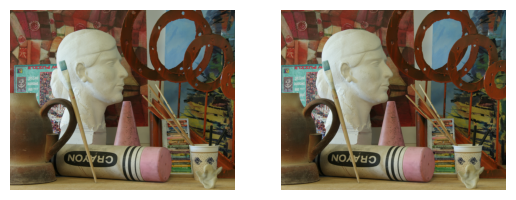

In [76]:
left = (plt.imread("src/view0.png") * 255).astype(np.float32)
right = (plt.imread("src/view1.png") * 255).astype(np.float32)
n = left.shape[1]
D = np.array([i for i in range(0, 64+1)])
fig, ax = plt.subplots(nrows=1, ncols=2)
ax[0].imshow(left.astype(np.uint8))
ax[0].axis("off")
ax[1].imshow(right.astype(np.uint8))
ax[1].axis("off")

In [57]:
def get_h(L, R, D, n):
    h = np.full((n, len(D)), fill_value=np.inf)
    for d in D:
        if d == 0:
            h[:, 0] = np.linalg.norm(L - R, axis=1)
        else:
            h[d:, d] = np.linalg.norm(L[d:] - R[:-d], axis=1)
    return h
def get_g(D, alpha):
    g = alpha * abs(D[:, None] - D[None, :])
    return g
def get_d_seq(h, g, D, n):
    f = h[0, :].copy()
    mins = np.zeros((n, len(D)), dtype=np.uint8)
    for i in range(1, n):
        mins[i] = np.argmin(f[:, None] + g, axis=0)
        f = np.min(f[:, None] + g, axis=0) + h[i, :]
    d_seq = np.zeros(n, dtype=np.uint8)
    d_seq[-1] = np.argmin(f)
    for i in range(n-2, 0-1, -1):
        d_seq[i] = mins[i+1, d_seq[i+1]]
    return d_seq
def get_res(left, right, D, n, g):
    res = np.zeros((left.shape[0], left.shape[1]), dtype=np.uint8)
    for i in range(left.shape[0]):
        h = get_h(left[i], right[i], D, n)
        res[i] = get_d_seq(h, g, D, n)
    return res


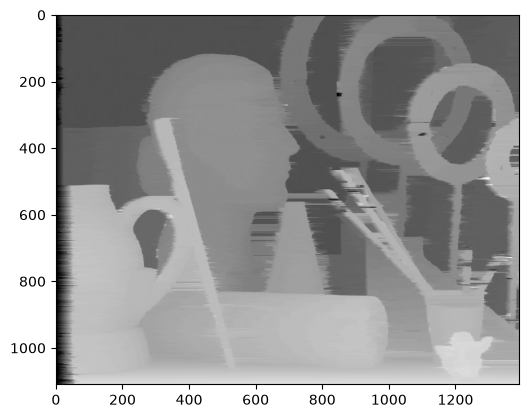

In [77]:
g = get_g(D, 20)
res = get_res(left, right, D, n, g)
plt.imshow(res, cmap="gray")

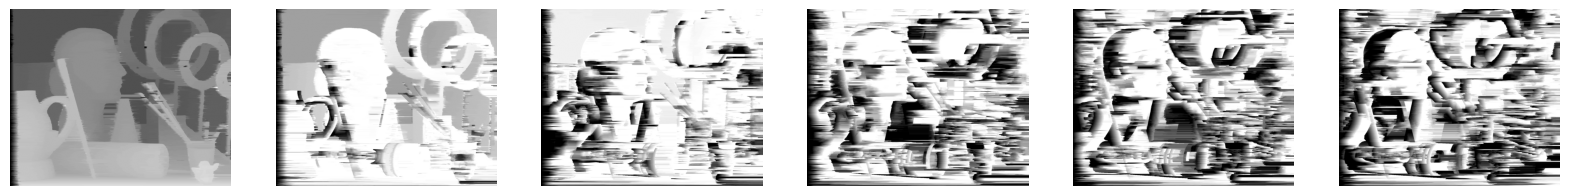

In [78]:
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(20, 5))
ax[0].imshow(res.astype(np.uint8), cmap="gray")
ax[0].axis("off")
for i in range(2, 6+1):
    right = (plt.imread(f"src/view{i}.png") * 255).astype(np.float32)
    res = get_res(left, right, D, n, g)
    ax[i-1].imshow(res.astype(np.uint8), cmap="gray")
    ax[i-1].axis("off")

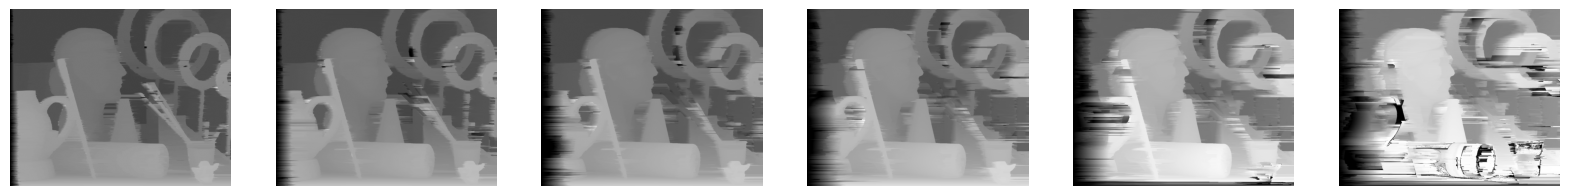

In [81]:
D = np.array([i for i in range(0, 256+1)])
g = get_g(D, 20)
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(20, 5))
for i in range(1, 6+1):
    right = (plt.imread(f"src/view{i}.png") * 255).astype(np.float32)
    res = get_res(left, right, D, n, g)
    ax[i-1].imshow(res.astype(np.uint8), cmap="gray")
    ax[i-1].axis("off")